# Dataset description

In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.analysis.behavior import population_analysis as behavior_population_analysis
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot_trial_average
from physion.utils import plot_tools as pt

# disable UserWarning from pynwb
import warnings
warnings.filterwarnings("ignore")

## loading the set of nwb files

In [2]:
if 'yann' in os.path.expanduser('~'):
    datafolder = os.path.join(os.path.expanduser('~'), 'CURATED' , 'NDNF-December-2022') # for yann
else: # means baptiste
    datafolder = os.path.join(os.path.expanduser('~'), 'Documents', 'ICMProjet','modulation-V1-processing','data','NDNF-December-2022')
    
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "/home/yann.zerlaut/CURATED/NDNF-December-2022" [...]
 -> found n=14 datafiles (in 2.7s) 


In [3]:
#behavior_population_analysis(SESSIONS['files'])

## Plotting the full time course and the average visually-evoked activity

### 1) Plotting the full time course

In [4]:
def plot_full_time_course(data):
    fig, _ = plot_raw(data, data.tlim, 
                      settings={'Locomotion':dict(fig_fraction=1, subsampling=1, color='tab:blue'),
                                'FaceMotion':dict(fig_fraction=1, subsampling=1, color='tab:purple'),
                                'Pupil':dict(fig_fraction=1, subsampling=1, color='tab:red'),
                                'CaImaging':dict(fig_fraction=3, subsampling=1, 
                                                 subquantity='dF/F', color='tab:green',
                                                 roiIndices=np.random.choice(range(data.vNrois),8)),
                                'CaImagingRaster':dict(fig_fraction=2, subsampling=1,
                                                       roiIndices='all',
                                                       normalization='per-line',
                                                       subquantity='dF/F')},
                                Tbar=20, figsize=(7,4))
    fig.suptitle(data.filename)
    return fig

### 2) Plotting the the average visually-evoked activity

In [5]:
protocols = ['moving-dots', 'random-dots', 'looming-stim', 'static-patch',
             'Natural-Images-4-repeats', 'drifting-gratings']

STAT_TEST = {}
for protocol in protocols:
    # a default stat test
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]
    
def plot_average_visually_evoked_activity(data,
                                          roiIndex=None,
                                          with_sd=True):
    
    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,4.5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        episodes = EpisodeData(data, 
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)
            plot_trial_average(episodes, 
                               roiIndex=roiIndex,
                               condition=stim_cond,
                               with_stat_test=True,
                               stat_test_props=STAT_TEST[protocol],
                               with_std=True,
                               with_std_over_trials = (with_sd if (roiIndex is not None) else False),
                               with_std_over_rois = (with_sd if (roiIndex is None) else False),
                               AX=[[AX[i][p]]])

            if len(varied_keys)==1:
                AX[i][p].annotate('%s=%s' % (varied_keys[0], values[0]),
                                  (0,0), fontsize=4,
                                  rotation=90, ha='right',
                                  xycoords='axes fraction')
                

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session \n --> mean$\pm$s.d. over n=%i ROIs' % data.nROIs, (0, 0),
                           xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i \n --> mean$\pm$s.d. over n=10 trials' % (1+roiIndex), (0, 0),
                           xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0):
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

In [ ]:
episodes.

### Testing

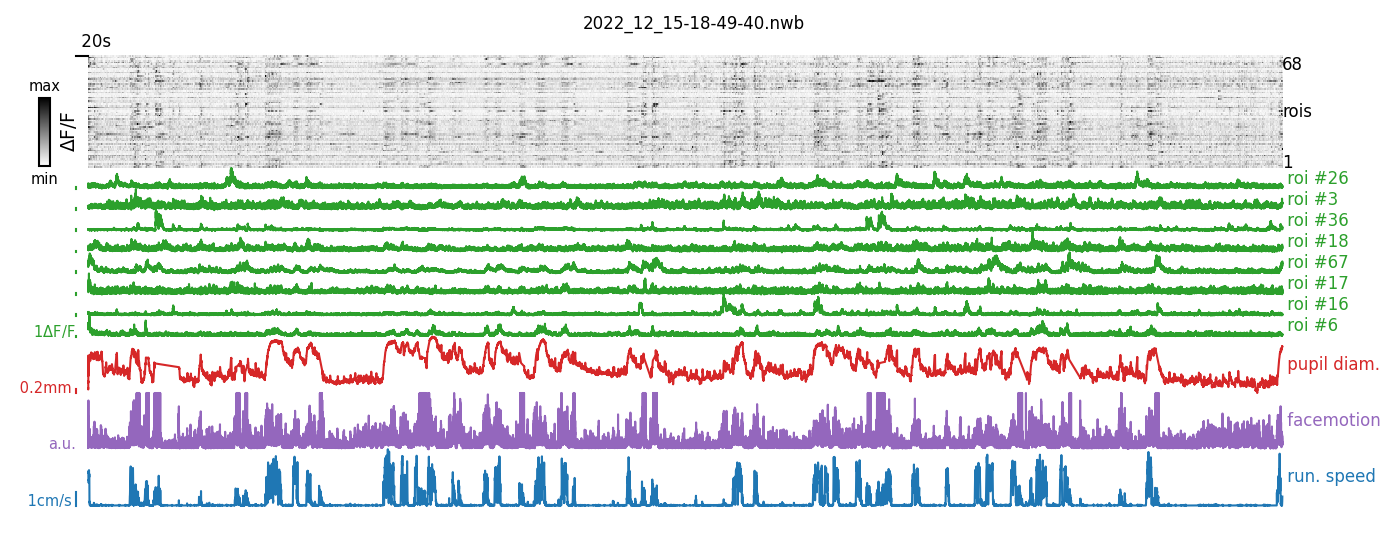

In [6]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)
fig = plot_full_time_course(data)
fig.subplots_adjust(left=0.08, top=0.95)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'fig.png'))

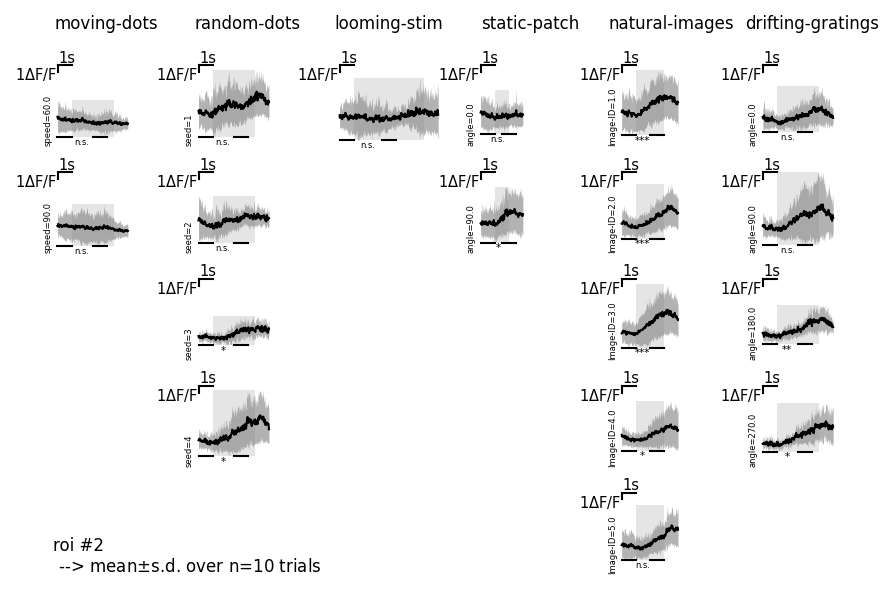

In [8]:
fig = plot_average_visually_evoked_activity(data, roiIndex=1, with_sd=True)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'fig.png'))

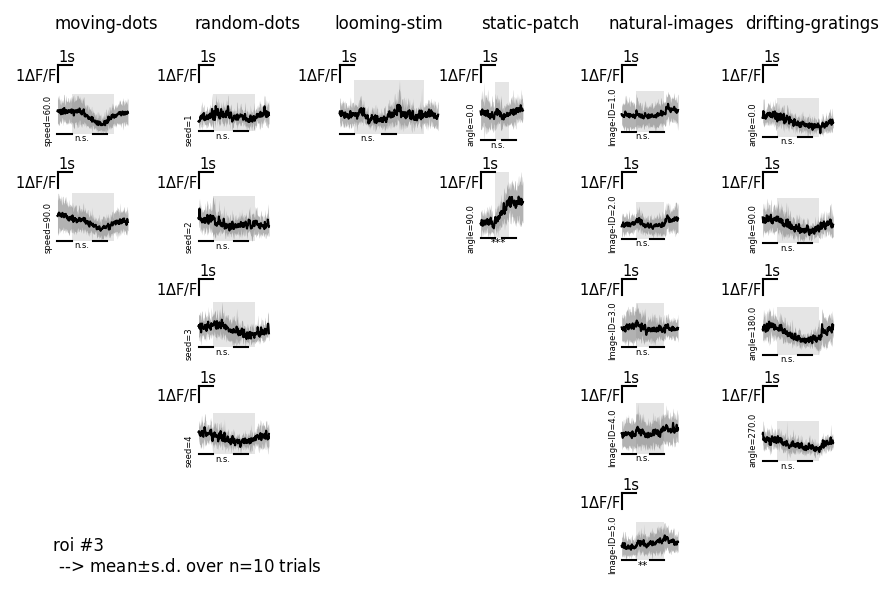

In [9]:
fig = plot_average_visually_evoked_activity(data, roiIndex=2, with_sd=True)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'fig.png'))

In [22]:
from physion.analysis.dataframe import NWB_to_dataframe
nwb = NWB_to_dataframe(filename)

NWB-file reading time: 221.0ms
 /!\ ROIs did not go through the "positive F0" criterion /!\ 
       --> need to call "data.build_dFoF()" first !  
 /!\ ROIs did not go through the "positive F0" criterion /!\ 
       --> need to call "data.build_dFoF()" first !  

calculating dF/F with method "maximin" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.4s)
 /!\ ValueError: A value in x_new is above the interpolation range /!\ 
   -->  interpolated at boundaries with mean value 
 /!\ ValueError: A value in x_new is above the interpolation range /!\ 
   -->  interpolated at boundaries with mean value 
 /!\ ValueError: A value in x_new is above the interpolation range /!\ 
   -->  interpolated at boundaries with mean value 
 /!\ ValueError: A value in x_new is above the interpolation range /!\ 
   -->  interpolated at boundaries with mean value 
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building ep

0        False
1        False
2        False
3        False
4        False
         ...  
59567    False
59568    False
59569    False
59570    False
59571    False
Name: VisStim_moving-dots, Length: 59572, dtype: bool

Text(0.5, 1.0, 'roi #2, 2022_12_15-18-49-40.nwb          ')

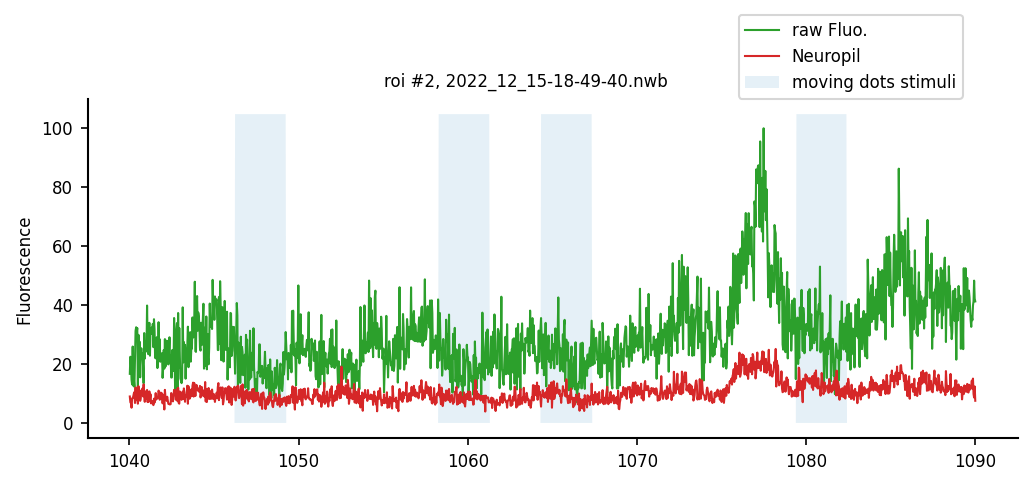

In [39]:
t0, width = 1040, 50
cond = (data.t_rawFluo>t0) & (data.t_rawFluo<(t0+width))
plt.subplots(1, figsize=(8,3))
plt.plot(data.t_rawFluo[cond], data.rawFluo[2,:][cond], color='tab:green', label='raw Fluo.')
plt.plot(data.t_rawFluo[cond], data.neuropil[2,:][cond], color='tab:red', label='Neuropil')
cond = (data.t_rawFluo>t0) & (data.t_rawFluo<(t0+width))
plt.fill_between(nwb['time'][cond], 0*nwb['time'][cond],
                 plt.gca().get_ylim()[1]*nwb['VisStim_moving-dots'][cond], alpha=0.1,
                 label='moving dots stimuli')
plt.legend(loc=(.7, 1))
plt.ylabel('Fluorescence')
plt.title('roi #2, %s          ' % data.filename)

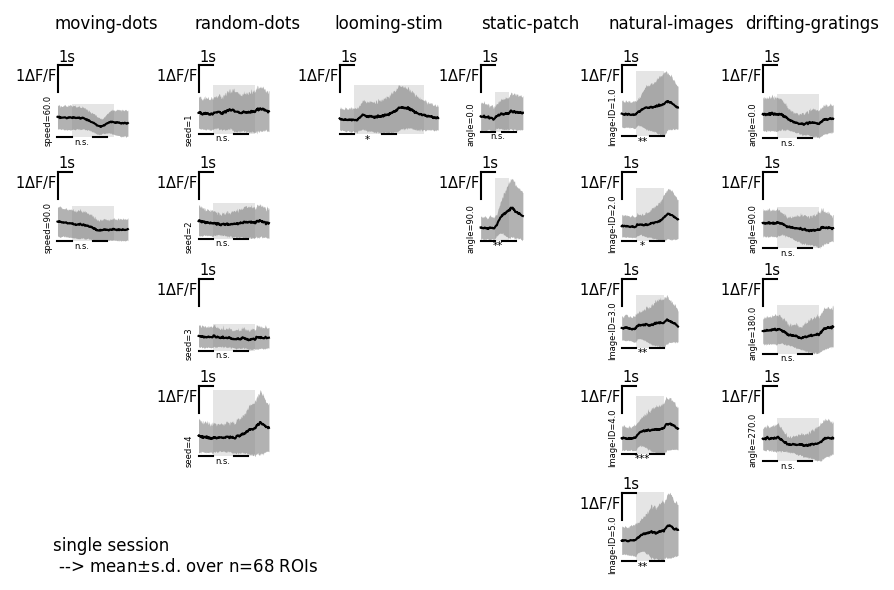

In [19]:
fig = plot_average_visually_evoked_activity(data)
fig.savefig(os.path.join(os.path.expanduser('~'), 'Desktop', 'fig.png'))

## Producing a pdf describing the dataset

In [2]:
if 'yann' in os.path.expanduser('~'):
    datafolder = os.path.join(os.path.expanduser('~'), 'CURATED' , 'NDNF-December-2022') # for yann
else: # means baptiste
    datafolder = os.path.join(os.path.expanduser('~'), 'Documents', 'ICMProjet','modulation-V1-processing','data','NDNF-December-2022')
    
FILENAMES = ['2022_12_14-13-27-41.nwb',
             '2022_12_15-18-13-25.nwb',
             '2022_12_15-18-49-40.nwb',
             '2022_12_16-11-00-09.nwb',
             '2022_12_16-12-03-30.nwb',
             '2022_12_16-12-47-57.nwb',
             '2022_12_16-13-40-07.nwb',
             '2022_12_16-14-29-38.nwb',
             '2022_12_20-11-49-18.nwb',
             '2022_12_20-12-31-08.nwb',
             '2022_12_20-14-08-45.nwb']

### Single page for a single session